## Step 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings('ignore')

### Loading Dataset

In [4]:
data = pd.read_csv('loan_data.csv')
data.head()

,Loan_ID,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
0,LP001002,Male,No,5849,NaN,Y
1,LP001003,Male,Yes,4583,128.0,N
2,LP001005,Male,Yes,3000,66.0,Y
3,LP001006,Male,Yes,2583,120.0,Y
4,LP001008,Male,No,6000,141.0,Y


In [5]:
data.shape

(598, 6)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          598 non-null    object 
 1   Gender           598 non-null    object 
 2   Married          598 non-null    object 
 3   ApplicantIncome  598 non-null    int64  
 4   LoanAmount       577 non-null    float64
 5   Loan_Status      598 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 28.2+ KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,598.0,5292.252508,5807.265364,150.0,2877.5,3806.0,5746.0,81000.0
LoanAmount,577.0,144.968804,82.704182,9.0,100.0,127.0,167.0,650.0


### Exploratory Data Analysis

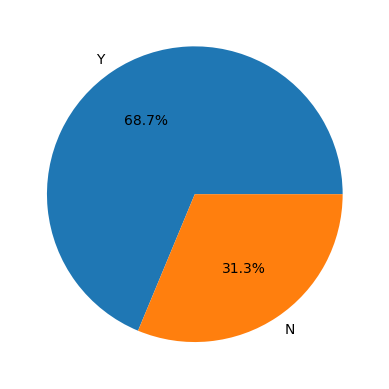

In [11]:
temp = data['Loan_Status'].value_counts()
plt.pie(temp.values, labels=temp.index, autopct='%1.1f%%')
plt.show()

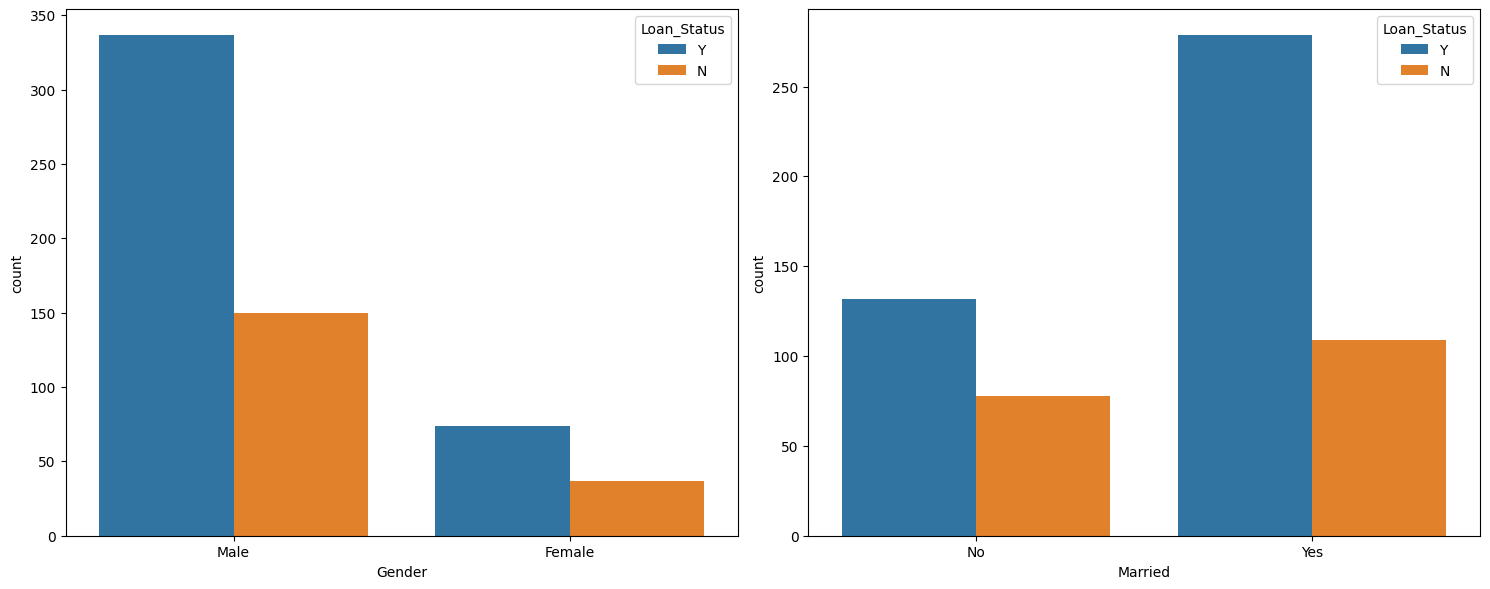

In [17]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(['Gender', 'Married']):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=data, x=col, hue='Loan_Status')

plt.tight_layout()
plt.show()

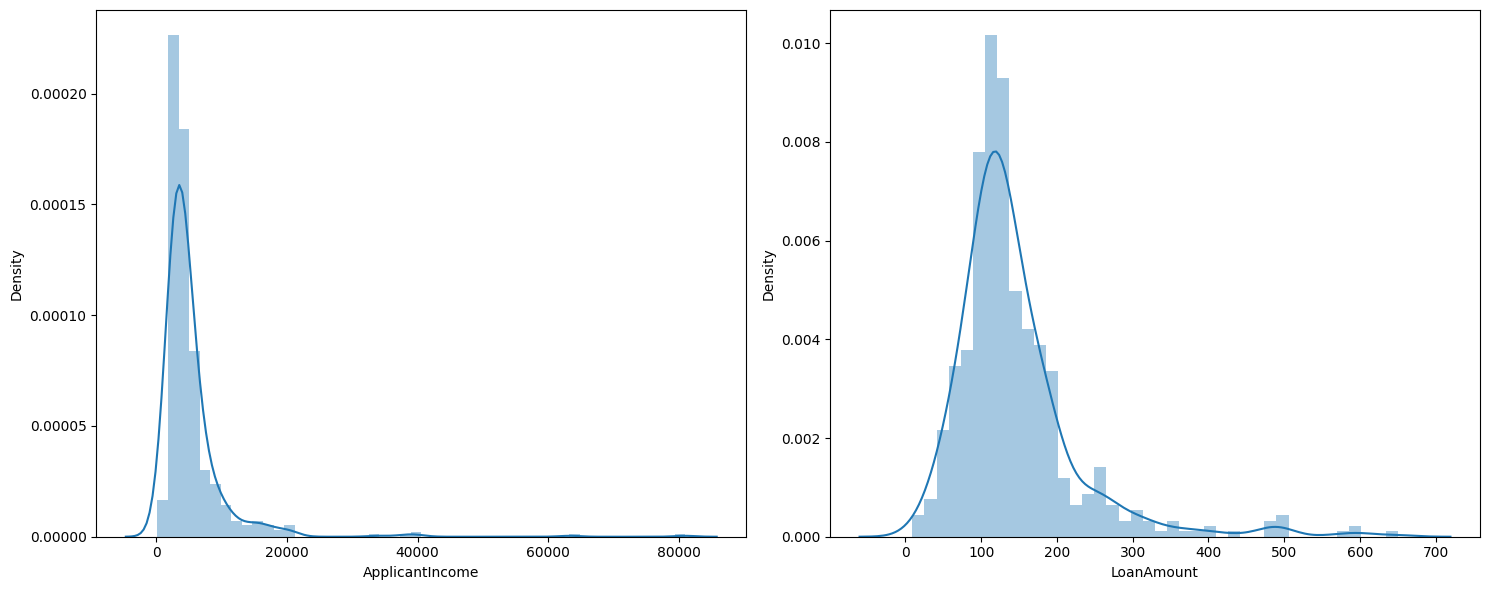

In [23]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(['ApplicantIncome', 'LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.distplot(data[col])
plt.tight_layout()
plt.show()

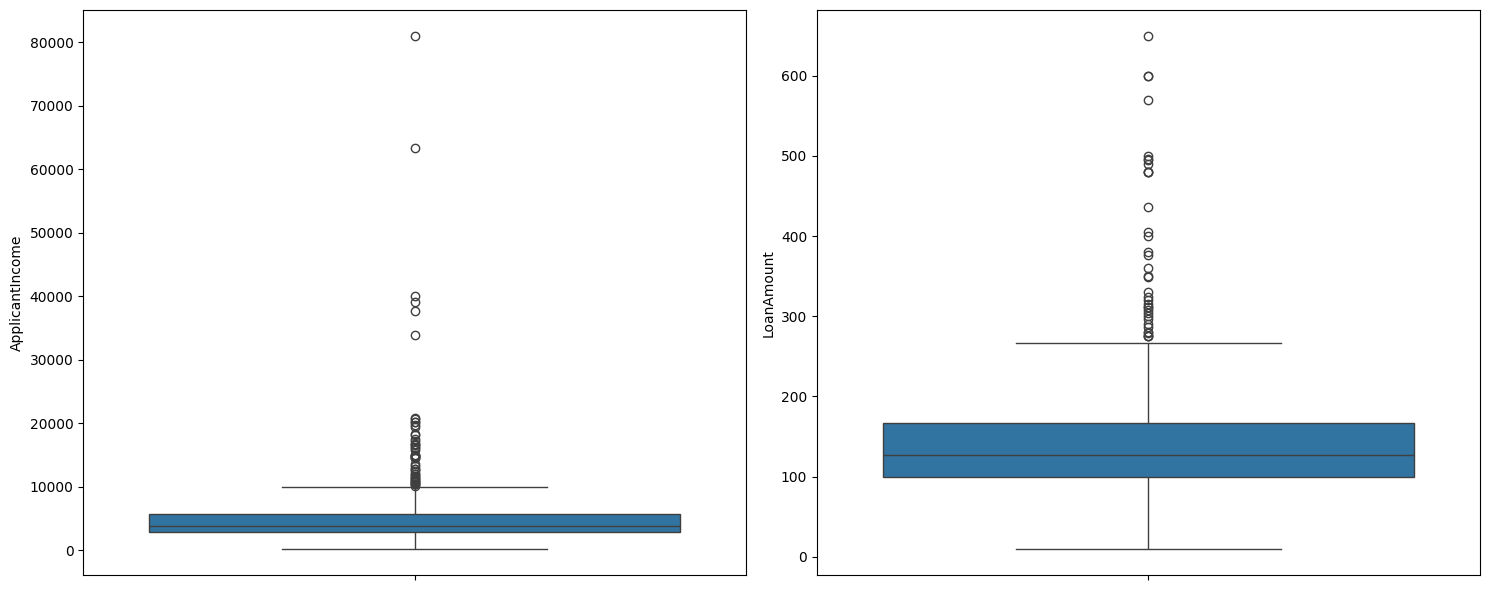

In [26]:
# Finding Outliers
plt.figure(figsize=(15, 6))
for i, col in enumerate(['ApplicantIncome', 'LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.boxplot(data[col])
plt.tight_layout()
plt.show()

In [27]:
data = data[data['ApplicantIncome'] < 25000]
data = data[data['LoanAmount'] < 400000]

In [28]:
data.groupby('Gender').mean(numeric_only=True)['LoanAmount']

Gender
Female    126.697248
Male      146.872294
Name: LoanAmount, dtype: float64

In [29]:
data.groupby(['Gender', 'Married']).mean(numeric_only=True)['LoanAmount']

Gender  Married
Female  No         116.115385
        Yes        153.322581
Male    No         135.959677
        Yes        150.875740
Name: LoanAmount, dtype: float64

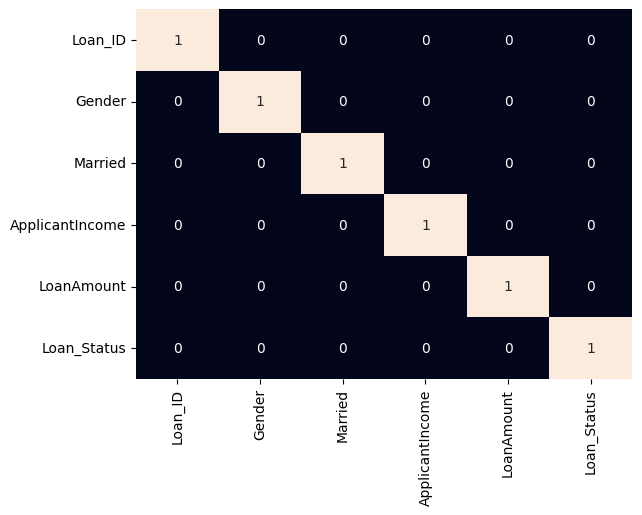

In [31]:
# Function to apply Label Encoding
def encode_labels(data1):
    for col in data1.columns:
        if data1[col].dtypes == 'object':
            le = LabelEncoder()
            data1[col] = le.fit_transform(data1[col])
    
    return data1

# Applying func in whole dataset
data = encode_labels(data)

# Generating Heatmap
sns.heatmap(data.corr() > 0.8, annot=True, cbar=False)
plt.show()

### 4. Data Preprocessing

In [33]:
features = data.drop(columns='Loan_Status', axis=1)
target = data['Loan_Status'].values

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=10)

ros = RandomOverSampler(sampling_strategy='minority', random_state=0)
X,  Y = ros.fit_resample(X_train, y_train)
X_train.shape, X.shape

((456, 5), (638, 5))

In [35]:
# Using Z-scale / Standarization
scaler = StandardScaler()
X =  scaler.fit_transform(X)
X_test = scaler.transform(X_test)

### Step 5. Model Development

In [39]:
from sklearn.metrics import roc_auc_score
model = SVC(kernel='rbf')
model.fit(X, Y)
print("The accuracy is ", metrics.roc_auc_score(Y, model.predict(X)))
print('Validation Accuracy : ', metrics.roc_auc_score(y_test, model.predict(X_test)))
print()

The accuracy is  0.6300940438871474
Validation Accuracy :  0.48198198198198194



### Step 6. Model Evaluation

In [42]:
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.svm import SVC

# Ensure probability=True is set when training the SVC model
model = SVC(probability=True)
model.fit(X, Y)

# Use decision scores or predicted probabilities for class 1
training_roc_auc = roc_auc_score(Y, model.predict_proba(X)[:, 1])
validation_roc_auc = roc_auc_score(
    y_test, model.predict_proba(X_test)[:, 1]
)  # Fixed extra tuple parenthesis

print("Training ROC AUC Score:", training_roc_auc)
print("Validation ROC AUC Score:", validation_roc_auc)
print()

# Use predict() for confusion matrix (requires hard class labels)
cm = confusion_matrix(y_test, model.predict(X_test))

Training ROC AUC Score: 0.6888395357750021
Validation ROC AUC Score: 0.5388080388080388



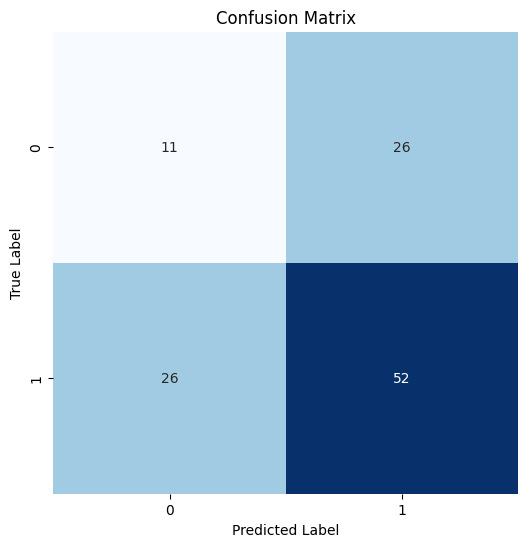

In [44]:
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_test)))


              precision    recall  f1-score   support

           0       0.30      0.30      0.30        37
           1       0.67      0.67      0.67        78

    accuracy                           0.55       115
   macro avg       0.48      0.48      0.48       115
weighted avg       0.55      0.55      0.55       115

